# Keyword analysis

In [1]:
import polars as pl
import polars_corpus as plc


In [2]:
pl.Config.set_tbl_rows(25)
pl.Config.set_float_precision(3)

polars.config.Config

In [3]:
# bnc = pl.scan_parquet("bnc.parquet").set_sorted("file_id")
# speakers = pl.scan_parquet("bnc-speakers.parquet")
#
# speakers = speakers.filter(pl.col("sex").is_in(["m", "f"]))
# speakers.group_by("sex").len()
#
# bnc = (
#     bnc.filter(pl.col("text_type") == "CONVRSN")
#     .join(speakers, on="speaker_id", how="inner")
#     .with_columns(pl.col("token").str.to_lowercase().alias("norm"))
#)

amalgum = pl.read_parquet('../../examples/amalgum.parquet')

Stefanowitsch (2020), pp. 378–380

In [38]:
# male_keywords = plc.keywords(
#     target = bnc.filter(pl.col('sex')=='m'),
#     reference= bnc.filter(pl.col('sex')=='f'),
#     method='ll',
#     expr=pl.col('token').str.to_lowercase()
# ).select('token','target_df','LogLik').collect(engine="streaming")

academic_keywords = plc.keywords(
    target = amalgum.filter(pl.col('file_type')=='whow'),
    reference=  amalgum.filter(pl.col('file_type')!='whow'),
    method='ll',
    expr=pl.col('token').str.to_lowercase()
).select('token','target_df','LogLik')



In [39]:
academic_keywords.head(20)

token,target_df,LogLik
str,u32,f64
"""your""",610,26036.259
"""you""",621,22799.548
"""if""",614,6260.387
"""or""",617,4896.021
"""can""",602,3490.256
"""will""",588,3480.034
"""make""",511,3303.042
"""dog""",49,2269.532
""".""",630,2243.749


<Axes: >

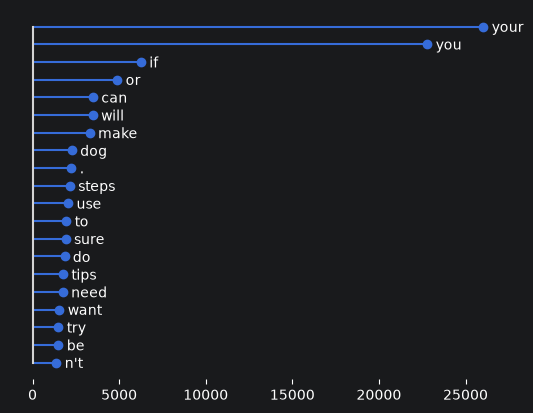

In [40]:
plc.keyword_plot(academic_keywords, 'token', 'LogLik', top_k=20, descending=True)

/var/folders/02/m5hrxwkj0cxf8_1x38m20vch0000gn/T/ipykernel_69186/1108015395.py:1: UserWarning: dropped 3 of 513,967 rows of the target corpus holding a null 'token'
  academic_keygrams = plc.keywords(
/var/folders/02/m5hrxwkj0cxf8_1x38m20vch0000gn/T/ipykernel_69186/1108015395.py:1: UserWarning: dropped 3 of 3,336,462 rows of the reference corpus holding a null 'token'
  academic_keygrams = plc.keywords(


<Axes: >

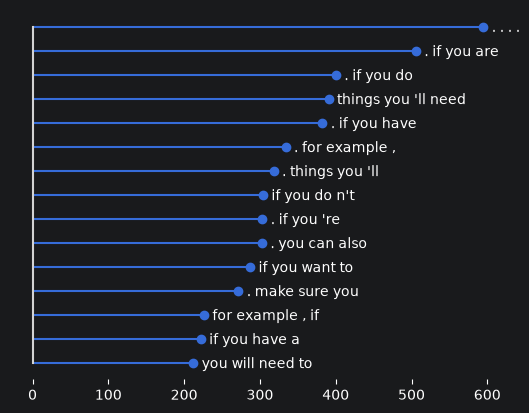

In [41]:
academic_keygrams = plc.keywords(
    target=amalgum.filter(pl.col('file_type') == 'whow'),
    reference=amalgum.filter(pl.col('file_type') != 'whow'),
    method='ll',
    min_target_tf=10,
    expr=plc.ngrams(4, 'token', as_str=True).str.to_lowercase()
).select('token', 'target_df', 'LogLik')

plc.keyword_plot(academic_keygrams, 'token', 'LogLik', top_k=15, descending=True)

Lijffijt et al. (2016)

In [42]:
academic_keywords = plc.keywords(
    target = amalgum.filter(pl.col('file_type')=='whow'),
    reference=  amalgum.filter(pl.col('file_type')!='whow'),
    method='ttest',
    expr=pl.col('token').str.to_lowercase()
)

<Axes: >

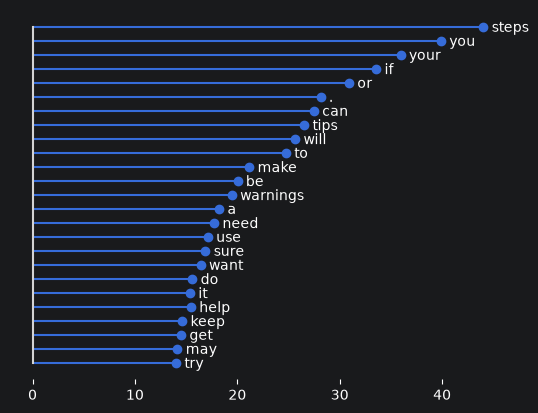

In [43]:
plc.keyword_plot(academic_keywords, 'token', 'stat', top_k=25, descending=True)

In [37]:
len(amalgum), len(amalgum.drop_nulls())

(3850429, 3850429)